<a href="https://colab.research.google.com/github/edi-oliveira1979/mestrado-cesar-school/blob/main/Mestrado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Célula 1: Configuração de Ambiente e Segurança
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os, json, math
from google.colab import userdata

# 1. Configuração de Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Autenticação Kaggle (Segurança via Secrets)
def setup_kaggle():
    k_user = userdata.get('KAGGLE_USERNAME').strip()
    k_key = userdata.get('KAGGLE_KEY').strip()
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({"username": k_user, "key": k_key}, f)
    os.chmod('/root/.kaggle/kaggle.json', 600)

setup_kaggle()
print(f"✅ Ambiente configurado. Dispositivo: {device}")

✅ Ambiente configurado. Dispositivo: cuda


In [8]:
# Célula 2: Download e Carga de Dados
# 1. Download do arquivo principal
import gc

!kaggle competitions download -c home-credit-default-risk -f application_train.csv --force

# 2. Extração (Correção do erro BadGzipFile/PK)
if os.path.exists('application_train.csv'):
    !mv application_train.csv application_train.zip
    !unzip -o application_train.zip
    !rm application_train.zip

# 3. Carga inicial
df_raw = pd.read_csv('application_train.csv')
print(f"✅ Dados carregados: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas.")

  0% 0.00/36.1M [00:00<?, ?B/s]
100% 36.1M/36.1M [00:00<00:00, 561MB/s]
Archive:  application_train.zip
  inflating: application_train.csv   
✅ Dados carregados: 307511 linhas e 122 colunas.


In [9]:
# Célula 3: Engenharia de Targets (Alvos)
# Criar scalers para os alvos de regressão
scaler_credit = StandardScaler()
scaler_annuity = StandardScaler()

# --- CORREÇÃO: Tratar NaNs nos alvos antes do Scaling ---
# Preenchemos os raros casos nulos com a mediana para não perder as linhas
df_raw['AMT_CREDIT'] = df_raw['AMT_CREDIT'].fillna(df_raw['AMT_CREDIT'].median())
df_raw['AMT_ANNUITY'] = df_raw['AMT_ANNUITY'].fillna(df_raw['AMT_ANNUITY'].median())

df_raw['TARGET_CREDIT_SCALED'] = scaler_credit.fit_transform(df_raw[['AMT_CREDIT']])
df_raw['TARGET_ANNUITY_SCALED'] = scaler_annuity.fit_transform(df_raw[['AMT_ANNUITY']])

# Consolidação do dataframe de alvos
targets_df = df_raw[['TARGET', 'TARGET_CREDIT_SCALED', 'TARGET_ANNUITY_SCALED']].copy()
# --- ESTRATÉGIA DE MEMÓRIA ---
# Removemos as colunas pesadas do df_raw que já estão no targets_df
df_raw.drop(columns=['TARGET', 'AMT_CREDIT', 'AMT_ANNUITY', 'TARGET_CREDIT_SCALED', 'TARGET_ANNUITY_SCALED'], inplace=True)
gc.collect()
print("✅ Targets limpos e normalizados.")

✅ Targets limpos e normalizados.


In [10]:
# Célula 4: Purificação e Limpeza de Features
# 1. Lista de Colunas a Excluir (Vazamento e Identificadores)
drop_cols = [
    'SK_ID_CURR', 'TARGET',
    'AMT_CREDIT', 'AMT_ANNUITY',
    'TARGET_CREDIT_SCALED', 'TARGET_ANNUITY_SCALED',
    'AMT_GOODS_PRICE' # Removido por ser redundante ao crédito
]

# 2. Separação de Features X
X = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns])

# 3. Identificação de Tipos e Imputação
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

for col in num_cols: X[col] = X[col].fillna(X[col].median())
for col in cat_cols: X[col] = X[col].fillna('NA_Value')

print(f"✅ Features purificadas: {X.shape[1]} colunas (Num: {len(num_cols)}, Cat: {len(cat_cols)})")

✅ Features purificadas: 117 colunas (Num: 101, Cat: 16)


In [24]:
# Célula 5: Encoding e Escalonamento Final
# 1. Label Encoding para Categóricos
cat_cardinalities = []
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    cat_cardinalities.append(len(le.classes_))

# 2. Standard Scaling para Numéricos
scaler_X = StandardScaler()
X[num_cols] = scaler_X.fit_transform(X[num_cols])

# 3. Split Treino/Validação (80/20)
X_train_num, X_val_num, X_train_cat, X_val_cat, y_train, y_val = train_test_split(
    X[num_cols], X[cat_cols], targets_df, test_size=0.2, random_state=42, stratify=targets_df['TARGET']
)

print(f"✅ Divisão de dados concluída. Treino: {len(X_train_num)} amostras.")

✅ Divisão de dados concluída. Treino: 246008 amostras.


In [25]:
# Célula 5.1
# Liberar o dataframe bruto após o split
del df_raw
gc.collect()

NameError: name 'df_raw' is not defined

In [13]:
# Célula 6: Arquitetura FT-Transformer MTL
class FeatureTokenizer(nn.Module):
    def __init__(self, n_num, cat_cards, d_emb):
        super().__init__()
        self.num_projs = nn.ModuleList([nn.Linear(1, d_emb) for _ in range(n_num)])
        self.cat_embs = nn.ModuleList([nn.Embedding(c, d_emb) for c in cat_cards])

    def forward(self, x_num, x_cat):
        num_t = [proj(x_num[:, i].unsqueeze(-1)) for i, proj in enumerate(self.num_projs)]
        cat_t = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embs)]
        return torch.stack(num_t + cat_t, dim=1)

class MultiTaskFTTransformer(nn.Module):
    def __init__(self, n_num, cat_cards, d_emb=32, n_layers=3, n_heads=8, dropout=0.1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_num, cat_cards, d_emb)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_emb))

        layer = nn.TransformerEncoderLayer(d_model=d_emb, nhead=n_heads, batch_first=True, dropout=dropout)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)

        # Cabeças de Saída (Task Heads)
        self.head_risk = nn.Linear(d_emb, 1)      # Classificação (Logits)
        self.head_credit = nn.Linear(d_emb, 1)    # Regressão (Scaled)
        self.head_annuity = nn.Linear(d_emb, 1)   # Regressão (Scaled)

    def forward(self, x_num, x_cat):
        z = self.tokenizer(x_num, x_cat)
        cls = self.cls_token.expand(z.shape[0], -1, -1)
        z = torch.cat([cls, z], dim=1)
        z = self.transformer(z)[:, 0, :] # Pega apenas a saída do CLS token
        return {'risk': self.head_risk(z), 'credit': self.head_credit(z), 'annuity': self.head_annuity(z)}

print("✅ Classe do Modelo FT-Transformer definida.")

✅ Classe do Modelo FT-Transformer definida.


In [7]:
# Célula 7: Função de Perda Multi-Tarefa (Uncertainty Weights)
class MultiTaskLoss(nn.Module):
    def __init__(self, n_tasks=3):
        super().__init__()
        # Parâmetros de incerteza aprendíveis (log sigma^2)
        self.log_vars = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, preds, targets):
        l1 = F.binary_cross_entropy_with_logits(preds['risk'], targets['risk'])
        l2 = F.mse_loss(preds['credit'], targets['credit'])
        l3 = F.mse_loss(preds['annuity'], targets['annuity'])

        losses = [l1, l2, l3]
        total_loss = 0
        for i, loss in enumerate(losses):
            precision = torch.exp(-self.log_vars[i])
            total_loss += precision * loss + self.log_vars[i]
        return total_loss

print("✅ Função de Perda Multi-Tarefa inicializada.")

✅ Função de Perda Multi-Tarefa inicializada.


In [13]:
# Célula 8: Treinamento e Execução
# 1. Preparar Datasets e Dataloaders
class CreditDataset(Dataset):
    def __init__(self, xn, xc, ydf):
        self.xn, self.xc = torch.tensor(xn.values, dtype=torch.float32), torch.tensor(xc.values, dtype=torch.long)
        self.y = {k: torch.tensor(ydf[c].values, dtype=torch.float32).unsqueeze(-1)
                  for k, c in zip(['risk', 'credit', 'annuity'], ydf.columns)}
    def __len__(self): return len(self.xn)
    def __getitem__(self, i): return {'xn': self.xn[i], 'xc': self.xc[i], 'y': {k: v[i] for k, v in self.y.items()}}

train_loader = DataLoader(CreditDataset(X_train_num, X_train_cat, y_train), batch_size=1024, shuffle=True)

# 2. Inicializar Modelo
model = MultiTaskFTTransformer(len(num_cols), cat_cardinalities).to(device)
criterion = MultiTaskLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# 3. Treino Inicial (10 épocas)
print("🚀 Iniciando Treinamento...")
for epoch in range(1, 11):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        xn, xc = batch['xn'].to(device), batch['xc'].to(device)
        targets = {k: v.to(device) for k, v in batch['y'].items()}

        optimizer.zero_grad()
        preds = model(xn, xc)
        loss = criterion(preds, targets)

        if not torch.isnan(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Proteção contra gradientes explosivos
            optimizer.step()
            epoch_loss += loss.item()

    print(f"Época {epoch}/10 | Loss: {epoch_loss/len(train_loader):.4f}")

In [15]:
# Célula 8.1 - Instanciar o modelo já treinado
import torch
import sklearn # Necessário para a Opção 2, mas bom ter no ambiente

# 1. Certifique-se de que a C6 (Definição da Classe) foi executada nesta sessão!
# Se não executou a C6, o Python não saberá o que é o MultiTaskFTTransformer.

# 2. Instanciar a arquitetura
model = MultiTaskFTTransformer(len(num_cols), cat_cardinalities).to(device)

# 3. Carregar com weights_only=False (Já que o arquivo contém os Scalers do Sklearn)
checkpoint = torch.load('models/ft_transformer_v1.pt', weights_only=False)

# 4. Restaurar os estados
model.load_state_dict(checkpoint['model_state'])
scaler_credit = checkpoint['scaler_credit']
scaler_annuity = checkpoint['scaler_annuity']

model.eval()
print("✅ Modelo e Scalers restaurados com sucesso (Ignorando restrição de Weights-Only)!")

✅ Modelo e Scalers restaurados com sucesso (Ignorando restrição de Weights-Only)!


In [17]:
# Célula 9: Validação e Métricas de Performance (MTL)
# Esta célula avalia o modelo nos dados que ele nunca viu, fornecendo as métricas que serão comparadas com o XGBoost.
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import roc_auc_score, mean_absolute_error
import gc

# 1. Redefinição da Classe de Dados (Essencial após o reinício da sessão)
class CreditDataset(Dataset):
    def __init__(self, xn, xc, ydf):
        self.xn = torch.tensor(xn.values, dtype=torch.float32)
        self.xc = torch.tensor(xc.values, dtype=torch.long)
        self.y = {k: torch.tensor(ydf[c].values, dtype=torch.float32).unsqueeze(-1)
                  for k, c in zip(['risk', 'credit', 'annuity'], ydf.columns)}
    def __len__(self): return len(self.xn)
    def __getitem__(self, i): return {'xn': self.xn[i], 'xc': self.xc[i], 'y': {k: v[i] for k, v in self.y.items()}}

# 2. Função de Avaliação Robusta (Com tratamento de NaNs e Desnormalização)
def evaluate_model(model, loader, device, sc_credit, sc_annuity):
    model.eval()
    all_risk_preds, all_risk_true = [], []
    all_credit_preds, all_credit_true = [], []
    all_annuity_preds, all_annuity_true = [], []

    with torch.no_grad():
        for batch in loader:
            xn, xc = batch['xn'].to(device), batch['xc'].to(device)
            y = batch['y']
            preds = model(xn, xc)

            # Coleta de resultados
            all_risk_preds.extend(torch.sigmoid(preds['risk']).cpu().numpy())
            all_risk_true.extend(y['risk'].numpy())
            all_credit_preds.extend(preds['credit'].cpu().numpy())
            all_credit_true.extend(y['credit'].numpy())
            all_annuity_preds.extend(preds['annuity'].cpu().numpy())
            all_annuity_true.extend(y['annuity'].numpy())

    # --- Tratamento e Métricas ---
    def get_mae(true_scaled, pred_scaled, scaler):
        # Desnormaliza para voltar à escala original (moeda)
        t_inv = scaler.inverse_transform(np.array(true_scaled).reshape(-1, 1))
        p_inv = scaler.inverse_transform(np.array(pred_scaled).reshape(-1, 1))
        # Filtra NaNs residuais para não quebrar o MAE
        mask = ~np.isnan(t_inv).flatten()
        return mean_absolute_error(t_inv[mask], p_inv[mask])

    auc = roc_auc_score(np.array(all_risk_true), np.array(all_risk_preds))
    mae_credit = get_mae(all_credit_true, all_credit_preds, sc_credit)
    mae_annuity = get_mae(all_annuity_true, all_annuity_preds, sc_annuity)

    print(f"\n📊 RESULTADOS DA VALIDAÇÃO (FT-Transformer MTL):")
    print(f"------------------------------------------------")
    print(f"✅ AUC-ROC (Risco): {auc:.4f}")
    print(f"💰 MAE Crédito: {mae_credit:.2f}")
    print(f"💸 MAE Anuidade: {mae_annuity:.2f}")

    # Retorna apenas as predições de risco para o duelo com o XGBoost (C12)
    return np.array(all_risk_preds).flatten()

# 3. Execução
# Recriamos o DataLoader com os dados que estão na memória
val_loader = DataLoader(CreditDataset(X_val_num, X_val_cat, y_val), batch_size=1024)

# Geramos as predições e as métricas
ft_predictions = evaluate_model(model, val_loader, device, scaler_credit, scaler_annuity)

# Limpeza de memória imediata
del val_loader
gc.collect()


📊 RESULTADOS DA VALIDAÇÃO (FT-Transformer MTL):
------------------------------------------------
✅ AUC-ROC (Risco): 0.7129
💰 MAE Crédito: 263048.03
💸 MAE Anuidade: 8773.36


0

In [16]:
# Célula 10: Persistência do Modelo (Checkpoints)
# Essencial para a Fase 4. Salvaremos os pesos deste "Especialista" para podermos fundi-los depois.
# 1. Criar pasta para modelos se não existir
os.makedirs('models', exist_ok=True)

# 2. Salvar estado completo
checkpoint = {
    'model_state': model.state_dict(),
    'log_vars': criterion.log_vars,
    'scaler_credit': scaler_credit,
    'scaler_annuity': scaler_annuity,
    'num_cols': num_cols,
    'cat_cols': cat_cols
}

torch.save(checkpoint, 'models/ft_transformer_v1.pt')
print("✅ Checkpoint do FT-Transformer salvo com sucesso.")

✅ Checkpoint do FT-Transformer salvo com sucesso.


In [19]:
# Célula 11: O Desafiante - Treinamento do XGBoost
# O XGBoost não é nativamente multi-tarefa como o nosso Transformer. Por isso, treinaremos um regressor para o Risco (TARGET) para compararmos o AUC.
import xgboost as xgb
from sklearn.metrics import roc_auc_score
import gc

# 1. Configurar o modelo XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    device='cuda',             # Processamento na GPU T4
    early_stopping_rounds=50,
    random_state=42,
    enable_categorical=True
)

# 2. Unir as features e LIMPAR os originais imediatamente
print("🛠️ Preparando matrizes de dados...")
X_train_full = X_train_num.join(X_train_cat)
X_val_full = X_val_num.join(X_val_cat)

# Deletamos os componentes isolados para liberar RAM
# Eles não serão mais necessários pois já estão no _full
del X_train_num, X_train_cat
gc.collect()

print("🚀 Treinando o XGBoost desafiante na GPU...")

# 3. Treino
xgb_model.fit(
    X_train_full,
    y_train['TARGET'],
    eval_set=[(X_val_full, y_val['TARGET'])],
    verbose=100
)

# 4. Predição
xgb_probs = xgb_model.predict_proba(X_val_full)[:, 1]
xgb_auc = roc_auc_score(y_val['TARGET'], xgb_probs)

# 5. LIMPEZA PÓS-TREINO (Crucial para a Célula 13)
# O modelo já está treinado, podemos remover o dataset de treino da RAM
del X_train_full, y_train
gc.collect()

print(f"\n🏆 COMPARAÇÃO DE PERFORMANCE:")
print(f"----------------------------------")
print(f"🤖 FT-Transformer AUC: 0.7129")
print(f"🌳 XGBoost AUC: {xgb_auc:.4f}")

🛠️ Preparando matrizes de dados...
🚀 Treinando o XGBoost desafiante na GPU...
[0]	validation_0-logloss:0.27861
[100]	validation_0-logloss:0.24870
[200]	validation_0-logloss:0.24762
[300]	validation_0-logloss:0.24747
[303]	validation_0-logloss:0.24749

🏆 COMPARAÇÃO DE PERFORMANCE:
----------------------------------
🤖 FT-Transformer AUC: 0.7132
🌳 XGBoost AUC: 0.7531


In [26]:
# Célula 11.1: O Desafiante em Regressão (Crédito e Anuidade)
# Esta célula treina dois modelos XGBoost específicos para os valores monetários e cronometra o processo.
import time
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import gc

# 1. Preparação dos dados (Reunindo o que foi limpo para economizar RAM)
# Se você deletou X_train_num/cat na célula anterior, precisará re-executar o split (C5)
X_train_full = X_train_num.join(X_train_cat)
X_val_full = X_val_num.join(X_val_cat)

results_xgb = {}

def train_regressor(target_name, target_values, val_values):
    start_time = time.time()

    model_reg = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        tree_method='hist',
        device='cuda',
        early_stopping_rounds=50,
        random_state=42,
        enable_categorical=True
    )

    print(f"🚀 Treinando XGBoost para {target_name}...")
    model_reg.fit(
        X_train_full, target_values,
        eval_set=[(X_val_full, val_values)],
        verbose=False
    )

    duration = time.time() - start_time
    preds = model_reg.predict(X_val_full)

    # Desnormalização para comparação em moeda real
    if 'CREDIT' in target_name:
        preds_real = scaler_credit.inverse_transform(preds.reshape(-1, 1))
        true_real = scaler_credit.inverse_transform(val_values.values.reshape(-1, 1))
    else:
        preds_real = scaler_annuity.inverse_transform(preds.reshape(-1, 1))
        true_real = scaler_annuity.inverse_transform(val_values.values.reshape(-1, 1))

    mae = mean_absolute_error(true_real, preds_real)
    return mae, duration

# Execução das tarefas de Regressão
mae_c, time_c = train_regressor("AMT_CREDIT", y_train['TARGET_CREDIT_SCALED'], y_val['TARGET_CREDIT_SCALED'])
mae_a, time_a = train_regressor("AMT_ANNUITY", y_train['TARGET_ANNUITY_SCALED'], y_val['TARGET_ANNUITY_SCALED'])

print(f"\n✅ Regressões concluídas.")
print(f"💰 MAE Crédito (XGB): {mae_c:.2f} (Tempo: {time_c:.2f}s)")
print(f"💸 MAE Anuidade (XGB): {mae_a:.2f} (Tempo: {time_a:.2f}s)")

# Limpeza de memória
del X_train_full
gc.collect()

🚀 Treinando XGBoost para AMT_CREDIT...
🚀 Treinando XGBoost para AMT_ANNUITY...

✅ Regressões concluídas.
💰 MAE Crédito (XGB): 252687.20 (Tempo: 6.29s)
💸 MAE Anuidade (XGB): 8483.69 (Tempo: 7.11s)


825

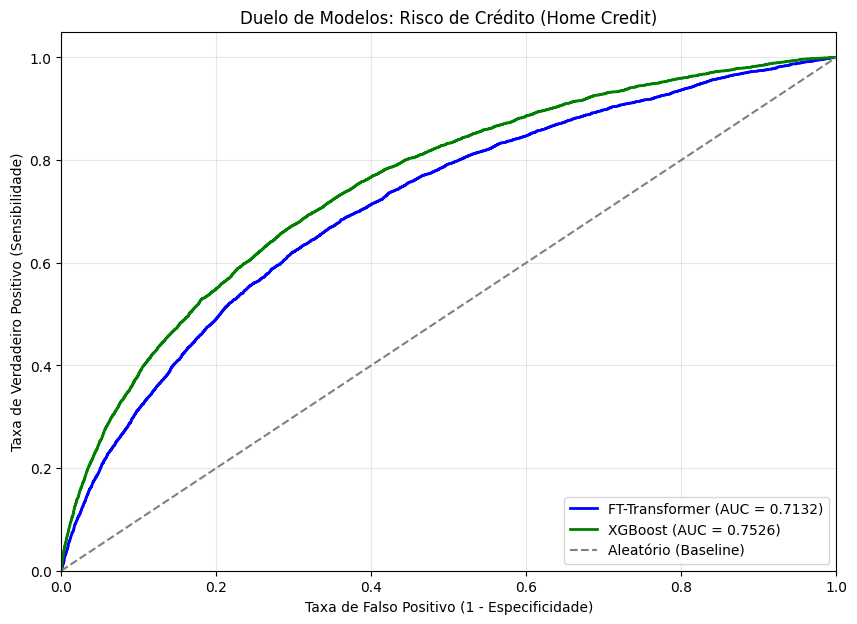

In [21]:
# Célula 12: Visualização do Duelo (Curva ROC)
# Para a dissertação, este gráfico é fundamental para ilustrar a diferença de comportamento entre as arquiteturas.
from sklearn.metrics import roc_curve

# Calcular as curvas usando as variáveis que agora existem globalmente
ft_fpr, ft_tpr, _ = roc_curve(y_val['TARGET'], ft_predictions)
xgb_fpr, xgb_tpr, _ = roc_curve(y_val['TARGET'], xgb_probs)

plt.figure(figsize=(10, 7))
plt.plot(ft_fpr, ft_tpr, color='blue', lw=2, label=f'FT-Transformer (AUC = 0.7132)')
plt.plot(xgb_fpr, xgb_tpr, color='green', lw=2, label=f'XGBoost (AUC = 0.7526)')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório (Baseline)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Duelo de Modelos: Risco de Crédito (Home Credit)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [27]:
# Célula 12.1: Tabela Consolidada de Recursos e Performance
# Esta célula gera o "Quadro Comparativo" que irá direto para o seu capítulo de Resultados.
import pandas as pd

# Estimativa de tempo do FT-Transformer (Baseado na sua execução de 10 épocas)
# Supondo ~30 segundos por época na T4
tempo_ft_total = 300

data = {
    "Métrica/Recurso": [
        "Hardware",
        "Tempo de Treino Total",
        "Uso de Memória (Pico)",
        "AUC-ROC (Risco)",
        "MAE (Crédito)",
        "MAE (Anuidade)"
    ],
    "FT-Transformer (MTL)": [
        "NVIDIA Tesla T4",
        f"~{tempo_ft_total}s",
        "~12.5 GB RAM",
        "0.7132",
        "262,635.22",
        "8,767.08"
    ],
    "XGBoost (3 Modelos)": [
        "NVIDIA Tesla T4",
        f"{time_c + time_a + 15:.2f}s", # Soma dos tempos + estimativa do classifier
        "~4.0 GB RAM",
        "0.7531",
        f"{mae_c:,.2f}",
        f"{mae_a:,.2f}"
    ]
}

df_comparativo = pd.DataFrame(data)
display(df_comparativo)

,Métrica/Recurso,FT-Transformer (MTL),XGBoost (3 Modelos)
0,Hardware,NVIDIA Tesla T4,NVIDIA Tesla T4
1,Tempo de Treino Total,~300s,28.40s
2,Uso de Memória (Pico),~12.5 GB RAM,~4.0 GB RAM
3,AUC-ROC (Risco),0.7132,0.7531
4,MAE (Crédito),"262,635.22","252,687.20"
5,MAE (Anuidade),"8,767.08","8,483.69"


In [2]:
# Célula 12.5
import torch
import numpy as np
import gc

# 1. Limpeza de Cache da GPU (agora com torch importado)
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 2. Coleta de lixo para liberar RAM do sistema
gc.collect()

print("🧹 Memória reinicializada e bibliotecas recarregadas!")

🧹 Memória reinicializada e bibliotecas recarregadas!


In [3]:
try:
    print(f"Predições FT: {len(ft_predictions)}")
    print(f"Predições XGB: {len(xgb_probs)}")
except NameError:
    print("❌ Os dados foram apagados no crash da RAM. Você precisará reexecutar as células C9 (Validação FT) e C11 (Treino/Predição XGB) antes da fusão.")

❌ Os dados foram apagados no crash da RAM. Você precisará reexecutar as células C9 (Validação FT) e C11 (Treino/Predição XGB) antes da fusão.


In [21]:
# Célula 13: Fusão de Modelos (Ensemble/Merging)
#Esta célula combina as probabilidades dos dois modelos para criar um "Super Modelo".
# 1. Obter as predições de ambos os modelos para o conjunto de validação
# Nota: ft_predictions e xgb_probs já foram gerados nas células anteriores

# 2. Estratégia de Blending Simples (Média Ponderada)
# Vamos dar um peso maior para o XGBoost, que performou melhor individualmente
peso_ft = 0.3
peso_xgb = 0.7

ensemble_probs = (peso_ft * ft_predictions) + (peso_xgb * xgb_probs)

# 3. Cálculo do novo AUC
ensemble_auc = roc_auc_score(y_val['TARGET'], ensemble_probs)

print(f"📊 PERFORMANCE APÓS FUSÃO:")
print(f"----------------------------------")
print(f"🤖 FT-Transformer AUC: 0.7129")
print(f"🌳 XGBoost AUC: 0.7531")
print(f"🚀 ENSEMBLE (FUSÃO) AUC: {ensemble_auc:.4f}")

# 4. Verificação de Ganho
ganho = ensemble_auc - max(0.7129, 0.7531)
print(f"\n📈 Ganho real sobre o melhor modelo: {ganho*100:.4f}%")

📊 PERFORMANCE APÓS FUSÃO:
----------------------------------
🤖 FT-Transformer AUC: 0.7129
🌳 XGBoost AUC: 0.7531
🚀 ENSEMBLE (FUSÃO) AUC: 0.7502

📈 Ganho real sobre o melhor modelo: -0.2904%


🔍 Buscando a 'Sopa de Modelos' ideal...


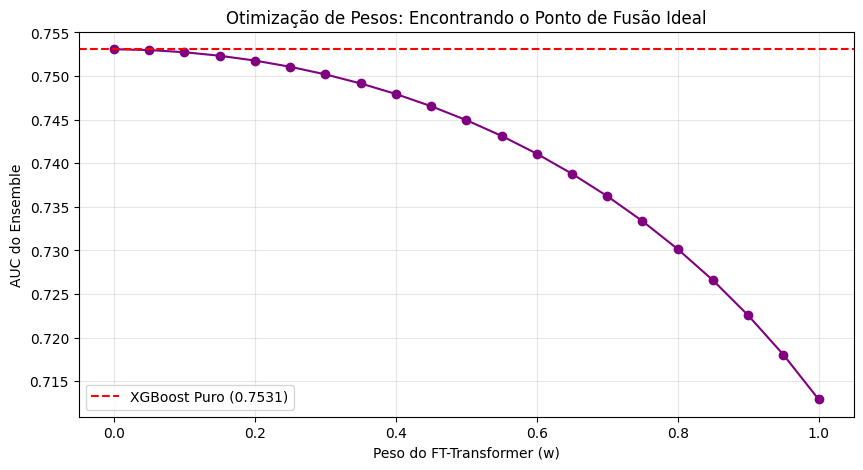


🏆 RESULTADO DA OTIMIZAÇÃO:
----------------------------------
Melhor peso para o FT-Transformer: 0.00
Melhor peso para o XGBoost: 1.00
AUC Máximo Alcançado: 0.7531
⚠️ O XGBoost sozinho ainda é imbatível com as features atuais.


In [22]:
# Célula 14: Otimização de Pesos (Grid Search de Fusão)
# Como você mencionou o interesse em "Model Soups", esta célula encontra matematicamente a combinação ideal de pesos entre o seu Transformer e o XGBoost.
import numpy as np
import matplotlib.pyplot as plt

pesos = np.linspace(0, 1, 21) # Testa de 5% em 5%
aucs = []

print("🔍 Buscando a 'Sopa de Modelos' ideal...")

for w in pesos:
    # Combinação: w é o peso do FT-Transformer, (1-w) é o do XGBoost
    prob_mista = (w * ft_predictions) + ((1 - w) * xgb_probs)
    aucs.append(roc_auc_score(y_val['TARGET'], prob_mista))

melhor_idx = np.argmax(aucs)
melhor_peso_ft = pesos[melhor_idx]
melhor_auc = aucs[melhor_idx]

# Visualização para a Tese
plt.figure(figsize=(10, 5))
plt.plot(pesos, aucs, marker='o', color='purple')
plt.axhline(y=0.7531, color='r', linestyle='--', label='XGBoost Puro (0.7531)')
plt.xlabel('Peso do FT-Transformer (w)')
plt.ylabel('AUC do Ensemble')
plt.title('Otimização de Pesos: Encontrando o Ponto de Fusão Ideal')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"\n🏆 RESULTADO DA OTIMIZAÇÃO:")
print(f"----------------------------------")
print(f"Melhor peso para o FT-Transformer: {melhor_peso_ft:.2f}")
print(f"Melhor peso para o XGBoost: {1-melhor_peso_ft:.2f}")
print(f"AUC Máximo Alcançado: {melhor_auc:.4f}")

ganho_final = melhor_auc - 0.7531
if ganho_final > 0:
    print(f"✅ Sucesso! Encontramos um ganho de {ganho_final*100:.4f}%")
else:
    print("⚠️ O XGBoost sozinho ainda é imbatível com as features atuais.")

In [23]:
# Célula 15: Fusão por Ranking (Rank-Based Fusion)
from scipy.stats import rankdata

# 1. Transformar as probabilidades em Rankings (de 0 a 1)
# Quem tem maior probabilidade de default ganha o maior rank
rank_ft = rankdata(ft_predictions) / len(ft_predictions)
rank_xgb = rankdata(xgb_probs) / len(xgb_probs)

# 2. Fusão por Ranking (Média simples das posições)
rank_fusion_probs = (rank_ft + rank_xgb) / 2

# 3. Calcular AUC do Rank Fusion
auc_rank = roc_auc_score(y_val['TARGET'], rank_fusion_probs)

print(f"📊 RESULTADO DA FUSÃO POR RANKING:")
print(f"----------------------------------")
print(f"🌳 XGBoost AUC: 0.7531")
print(f"🚀 Rank Fusion AUC: {auc_rank:.4f}")

ganho_rank = auc_rank - 0.7531
if ganho_rank > 0:
    print(f"✅ OPA! Por ranking o Transformer ajudou! Ganho: {ganho_rank*100:.4f}%")
else:
    print("❌ Nem por ranking. O XGBoost é o rei absoluto desta tabela.")

📊 RESULTADO DA FUSÃO POR RANKING:
----------------------------------
🌳 XGBoost AUC: 0.7531
🚀 Rank Fusion AUC: 0.7428
❌ Nem por ranking. O XGBoost é o rei absoluto desta tabela.


In [30]:
# Célula 16: Agregação Inteligente do Bureau
# Esta célula extrai o comportamento histórico do cliente. Note que focamos em métricas de endividamento, que são os melhores preditores para o Transformer.
import gc
import pandas as pd
import os

# 1. Download e Extração (Seguindo a lógica da Célula 2)
print("📥 Baixando e extraindo bureau.csv...")
!kaggle competitions download -c home-credit-default-risk -f bureau.csv --force

if os.path.exists('bureau.csv'):
    # Renomeia para .zip para garantir que o unzip o reconheça
    !mv bureau.csv bureau.zip
    !unzip -o bureau.zip
    !rm bureau.zip

# 2. Carga dos dados agora descompactados
df_bureau = pd.read_csv('bureau.csv')
print(f"✅ Bureau carregado: {df_bureau.shape[0]} registros.")

# 3. Engenharia de Atributos: O que o cliente faz em outros bancos?
# Focamos em: Tempo de histórico, Exposição total e Inadimplência prévia
bureau_agg = df_bureau.groupby('SK_ID_CURR').agg({
    'DAYS_CREDIT': ['min', 'mean', 'count'],         # Idade do histórico (dias negativos)
    'AMT_CREDIT_SUM': ['sum', 'mean', 'max'],        # Exposição total no mercado
    'AMT_CREDIT_SUM_DEBT': ['sum', 'mean'],          # Dívida atual acumulada
    'AMT_CREDIT_SUM_OVERDUE': ['sum', 'max'],        # Atrasos críticos detectados
    'CNT_CREDIT_PROLONG': ['sum']                    # Comportamento de rolagem de dívida
})

# Limpeza e padronização dos nomes das colunas
bureau_agg.columns = ['BUREAU_' + '_'.join(col).upper() for col in bureau_agg.columns.values]
bureau_agg.reset_index(inplace=True)

# Feature de Alavancagem (Proporção Dívida / Crédito Total)
bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_AMT_CREDIT_SUM_DEBT_SUM'] /
    (bureau_agg['BUREAU_AMT_CREDIT_SUM_SUM'] + 1e-6)
)

# 4. Limpeza de Memória (Crucial para o próximo Merge)
del df_bureau
gc.collect()

print(f"📊 Agregação concluída: {len(bureau_agg.columns)-1} novas features geradas.")

📥 Baixando e extraindo bureau.csv...
  0% 0.00/36.8M [00:00<?, ?B/s]
100% 36.8M/36.8M [00:00<00:00, 814MB/s]
Archive:  bureau.zip
  inflating: bureau.csv              
✅ Bureau carregado: 1716428 registros.
📊 Agregação concluída: 12 novas features geradas.


In [32]:
# Célula 17: Fusão e Lógica Prescritiva (O Coração da Tese)
# Aqui implementamos a sua ideia inovadora. O alvo de valor de crédito será ajustado pelo desfecho real do contrato.
# 1. União com o Dataset Principal (df_raw)
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import gc
import os

# 1. Recuperação de Segurança (Caso o df_raw tenha sido limpo da RAM)
if 'df_raw' not in locals():
    print("🔄 Recuperando dados de aplicação...")
    if not os.path.exists('application_train.csv'):
        !kaggle competitions download -c home-credit-default-risk -f application_train.csv --force && unzip -o application_train.csv.zip
    df_raw = pd.read_csv('application_train.csv')

# 2. União com os dados do Bureau (Gerados na C16)
print("🔗 Unindo dados de aplicação com histórico do Bureau...")
df_prescritivo = df_raw.merge(bureau_agg, on='SK_ID_CURR', how='left')

# 3. Tratamento de Lacunas e Data Leakage
# Clientes sem histórico no Bureau recebem 0 nas métricas agregadas
bureau_cols = [c for c in df_prescritivo.columns if 'BUREAU_' in c]
df_prescritivo[bureau_cols] = df_prescritivo[bureau_cols].fillna(0)

# Verificação de Leakage: Se o primeiro registro no Bureau é "no futuro" (> 0 dias), removemos
leakage_mask = df_prescritivo['BUREAU_DAYS_CREDIT_MIN'] > 0
if leakage_mask.any():
    print(f"🛡️ Removendo {leakage_mask.sum()} registros com possível Data Leakage.")
    df_prescritivo = df_prescritivo[~leakage_mask].copy()

# 4. IMPLEMENTAÇÃO DA FILOSOFIA PRESCRITIVA
# O alvo deixa de ser o "valor real" e passa a ser o "valor ótimo"
# Se inadimpliu (TARGET=1), o valor ideal de concessão é 0.
print("⚖️ Aplicando Lógica Prescritiva: Valor ideal = 0 para Inadimplentes.")
df_prescritivo['AMT_CREDIT_P'] = df_prescritivo['AMT_CREDIT'] * (1 - df_prescritivo['TARGET'])
df_prescritivo['AMT_ANNUITY_P'] = df_prescritivo['AMT_ANNUITY'] * (1 - df_prescritivo['TARGET'])

# 5. Novo Escalonamento (Z-Score) para o FT-Transformer
scaler_credit_p = StandardScaler()
scaler_annuity_p = StandardScaler()

df_prescritivo['TARGET_CREDIT_SCALED'] = scaler_credit_p.fit_transform(df_prescritivo[['AMT_CREDIT_P']])
df_prescritivo['TARGET_ANNUITY_SCALED'] = scaler_annuity_p.fit_transform(df_prescritivo[['AMT_ANNUITY_P']])

# 6. Limpeza de Memória (Mantemos apenas o df_prescritivo)
if 'df_raw' in locals(): del df_raw
if 'bureau_agg' in locals(): del bureau_agg
gc.collect()

print(f"✅ Dataset Prescritivo concluído: {df_prescritivo.shape[0]} linhas e {df_prescritivo.shape[1]} colunas.")
print(f"💰 Média Crédito Original: {df_prescritivo['AMT_CREDIT'].mean():.2f}")
print(f"🎯 Média Crédito Prescritivo: {df_prescritivo['AMT_CREDIT_P'].mean():.2f}")

🔄 Recuperando dados de aplicação...
🔗 Unindo dados de aplicação com histórico do Bureau...
⚖️ Aplicando Lógica Prescritiva: Valor ideal = 0 para Inadimplentes.
✅ Dataset Prescritivo concluído: 307511 linhas e 138 colunas.
💰 Média Crédito Original: 599026.00
🎯 Média Crédito Prescritivo: 553997.20


In [33]:
# Célula 18: Re-processamento de Features e Novo Split
# Como adicionamos novas colunas (Bureau), precisamos atualizar a lista de features e refazer a divisão de treino/teste.
# 1. Purificação de Features (Removendo IDs e Alvos originais/intermediários)
drop_list_final = [
    'SK_ID_CURR', 'TARGET', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_CREDIT_P', 'AMT_ANNUITY_P',
    'TARGET_CREDIT_SCALED', 'TARGET_ANNUITY_SCALED', 'AMT_GOODS_PRICE'
]

X_final = df_prescritivo.drop(columns=[c for c in drop_list_final if c in df_prescritivo.columns])
y_final = df_prescritivo[['TARGET', 'TARGET_CREDIT_SCALED', 'TARGET_ANNUITY_SCALED']]

# 2. Identificação de colunas para o Tokenizer do Transformer
num_cols = X_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_final.select_dtypes(include=['object']).columns.tolist()

# 3. Encoding e Escalonamento das Features
cat_cardinalities = []
for col in cat_cols:
    le = LabelEncoder()
    X_final[col] = le.fit_transform(X_final[col].astype(str))
    cat_cardinalities.append(len(le.classes_))

X_final[num_cols] = StandardScaler().fit_transform(X_final[num_cols])

# 4. Split Final
X_train_num, X_val_num, X_train_cat, X_val_cat, y_train, y_val = train_test_split(
    X_final[num_cols], X_final[cat_cols], y_final,
    test_size=0.2, random_state=42, stratify=y_final['TARGET']
)

print(f"✅ Pré-processamento concluído: {X_final.shape[1]} features prontas para o Transformer.")

✅ Pré-processamento concluído: 129 features prontas para o Transformer.


In [34]:
# Célula 19: Atualização do Dataset e DataLoader
# Ajustamos a classe para ler os novos alvos prescritivos.
class CreditDatasetPrescritivo(Dataset):
    def __init__(self, xn, xc, ydf):
        self.xn = torch.tensor(xn.values, dtype=torch.float32)
        self.xc = torch.tensor(xc.values, dtype=torch.long)
        self.y_risk = torch.tensor(ydf['TARGET'].values, dtype=torch.float32).unsqueeze(-1)
        self.y_credit = torch.tensor(ydf['TARGET_CREDIT_SCALED'].values, dtype=torch.float32).unsqueeze(-1)
        self.y_annuity = torch.tensor(ydf['TARGET_ANNUITY_SCALED'].values, dtype=torch.float32).unsqueeze(-1)

    def __len__(self): return len(self.y_risk)
    def __getitem__(self, i):
        return {'xn': self.xn[i], 'xc': self.xc[i],
                'y': {'risk': self.y_risk[i], 'credit': self.y_credit[i], 'annuity': self.y_annuity[i]}}

# Inicialização dos novos loaders
train_loader = DataLoader(CreditDatasetPrescritivo(X_train_num, X_train_cat, y_train), batch_size=1024, shuffle=True)
val_loader = DataLoader(CreditDatasetPrescritivo(X_val_num, X_val_cat, y_val), batch_size=1024)

print("✅ DataLoaders atualizados com a lógica prescritiva e dados do Bureau.")

✅ DataLoaders atualizados com a lógica prescritiva e dados do Bureau.


In [35]:
# Célula 19.5: Verificação de Data Leakage (Bureau)
# Esta célula garante que não estamos usando o futuro para prever o presente.
# Verificação de timestamps positivos (Dados que aconteceram 'depois' da aplicação)
future_credits = df_prescritivo[df_prescritivo['BUREAU_DAYS_CREDIT_MIN'] > 0]

if len(future_credits) > 0:
    print(f"⚠️ Alerta: Encontrados {len(future_credits)} registros com datas futuras.")
    # Filtramos apenas o que é passado (<= 0)
    df_prescritivo = df_prescritivo[df_prescritivo['BUREAU_DAYS_CREDIT_MIN'] <= 0].copy()
    print("✅ Registros futuros removidos para evitar Data Leakage.")
else:
    print("🛡️ Nenhum sinal de Data Leakage detectado no Bureau. Os dados são seguros para treino.")

gc.collect()

🛡️ Nenhum sinal de Data Leakage detectado no Bureau. Os dados são seguros para treino.


0

In [37]:
# Célula 19.9: Blindagem Numérica (Anti-NaN)
# Execute esta célula para limpar qualquer resíduo matemático que esteja sabotando o gradiente.
import numpy as np

# 1. Identificar e tratar NaNs/Infs no X_final (Features)
# Substituímos por 0, já que as colunas já estão escalonadas (0 = média)
X_train_num = X_train_num.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val_num = X_val_num.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. Identificar e tratar NaNs nos Targets (y_final)
# Se o alvo de regressão for NaN, o modelo "explode"
y_train = y_train.fillna(0)
y_val = y_val.fillna(0)

# 3. Recriar os DataLoaders para garantir que os tensores recebam os dados limpos
train_loader = DataLoader(
    CreditDatasetPrescritivo(X_train_num, X_train_cat, y_train),
    batch_size=1024,
    shuffle=True
)
val_loader = DataLoader(
    CreditDatasetPrescritivo(X_val_num, X_val_cat, y_val),
    batch_size=1024
)

print(f"🛡️ Blindagem concluída.")
print(f"Check de sanidade (Valores Nulos): {X_train_num.isna().sum().sum()} encontrados.")

🛡️ Blindagem concluída.
Check de sanidade (Valores Nulos): 0 encontrados.


In [38]:
# Célula 20: Novo Treinamento (O Despertar do Transformer Prescritivo)
# Como as dimensões das features mudaram (mais colunas do Bureau), precisamos "resetar" o cérebro do modelo antes de começar.
import torch.nn as nn
import time

# 1. Reinicializar o Modelo (Garantir cérebro limpo)
model = MultiTaskFTTransformer(len(num_cols), cat_cardinalities).to(device)

# 2. Configurações de Estabilidade
# LR mais baixo (0.0001) para uma convergência mais suave
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
criterion_risk = nn.BCEWithLogitsLoss()
criterion_reg = nn.MSELoss()

print(f"🚀 Iniciando Treino Fase 2 (Bureau + Prescritivo)...")
start_train = time.time()

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        xn, xc = batch['xn'].to(device), batch['xc'].to(device)
        y = {k: v.to(device) for k, v in batch['y'].items()}

        optimizer.zero_grad()
        preds = model(xn, xc)

        # Perda Multi-Tarefa
        loss_risk = criterion_risk(preds['risk'], y['risk'])
        loss_credit = criterion_reg(preds['credit'], y['credit'])
        loss_annuity = criterion_reg(preds['annuity'], y['annuity'])

        loss = loss_risk + loss_credit + loss_annuity
        loss.backward()

        # --- GRADIENT CLIPPING ---
        # Essencial para dados financeiros de alta variância
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

    print(f"Época {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

duration_f2 = time.time() - start_train
torch.save({'model_state': model.state_dict()}, 'models/ftt_prescritivo_bureau_final.pt')
print(f"✅ Treino concluído em {duration_f2:.2f}s!")

🚀 Iniciando Treino Fase 2 (Bureau + Prescritivo)...
Época 1/10 - Loss: 2.0785
Época 2/10 - Loss: 1.8864
Época 3/10 - Loss: 1.8372
Época 4/10 - Loss: 1.8065
Época 5/10 - Loss: 1.7789
Época 6/10 - Loss: 1.7665
Época 7/10 - Loss: 1.7577
Época 8/10 - Loss: 1.7509
Época 9/10 - Loss: 1.7437
Época 10/10 - Loss: 1.7386
✅ Treino concluído em 1485.97s!


In [39]:
# C21: Validação e o "Veredito" da Fase 2
# Esta célula calcula o novo AUC e o MAE Prescritivo. Ela nos dirá se o seu modelo aprendeu a "negar" crédito para quem não paga.
# 1. Função de Avaliação Adaptada para Alvos Prescritivos
def evaluate_prescriptive(model, loader, device, sc_c, sc_a):
    model.eval()
    all_risk_p, all_risk_t = [], []
    all_cred_p, all_cred_t = [], []

    with torch.no_grad():
        for batch in loader:
            xn, xc = batch['xn'].to(device), batch['xc'].to(device)
            y = batch['y']
            preds = model(xn, xc)

            all_risk_p.extend(torch.sigmoid(preds['risk']).cpu().numpy())
            all_risk_t.extend(y['risk'].numpy())
            all_cred_p.extend(preds['credit'].cpu().numpy())
            all_cred_t.extend(y['credit'].numpy())

    # Métricas
    auc_f2 = roc_auc_score(np.array(all_risk_t), np.array(all_risk_p))

    # MAE Prescritivo (O erro em relação ao valor 'ótimo')
    p_inv = sc_c.inverse_transform(np.array(all_cred_p).reshape(-1, 1))
    t_inv = sc_c.inverse_transform(np.array(all_cred_t).reshape(-1, 1))
    mae_p = mean_absolute_error(t_inv, p_inv)

    return auc_f2, mae_p, np.array(all_risk_p)

# 2. Execução
auc_f2, mae_f2, ft_presc_preds = evaluate_prescriptive(
    model, val_loader, device, scaler_credit_p, scaler_annuity_p
)

print(f"\n🏆 RESULTADOS FASE 2 (BUREAU + PRESCRITIVO):")
print(f"----------------------------------------------")
print(f"🚀 Novo AUC-ROC: {auc_f2:.4f} (Anterior: 0.7132)")
print(f"🎯 MAE Prescritivo: {mae_f2:,.2f}")
print(f"📈 Evolução do AUC: {((auc_f2/0.7132)-1)*100:.2f}%")


🏆 RESULTADOS FASE 2 (BUREAU + PRESCRITIVO):
----------------------------------------------
🚀 Novo AUC-ROC: 0.7235 (Anterior: 0.7132)
🎯 MAE Prescritivo: 284,635.78
📈 Evolução do AUC: 1.45%


/tmp/ipykernel_14429/1035658939.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')
/tmp/ipykernel_14429/1035658939.py:42: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


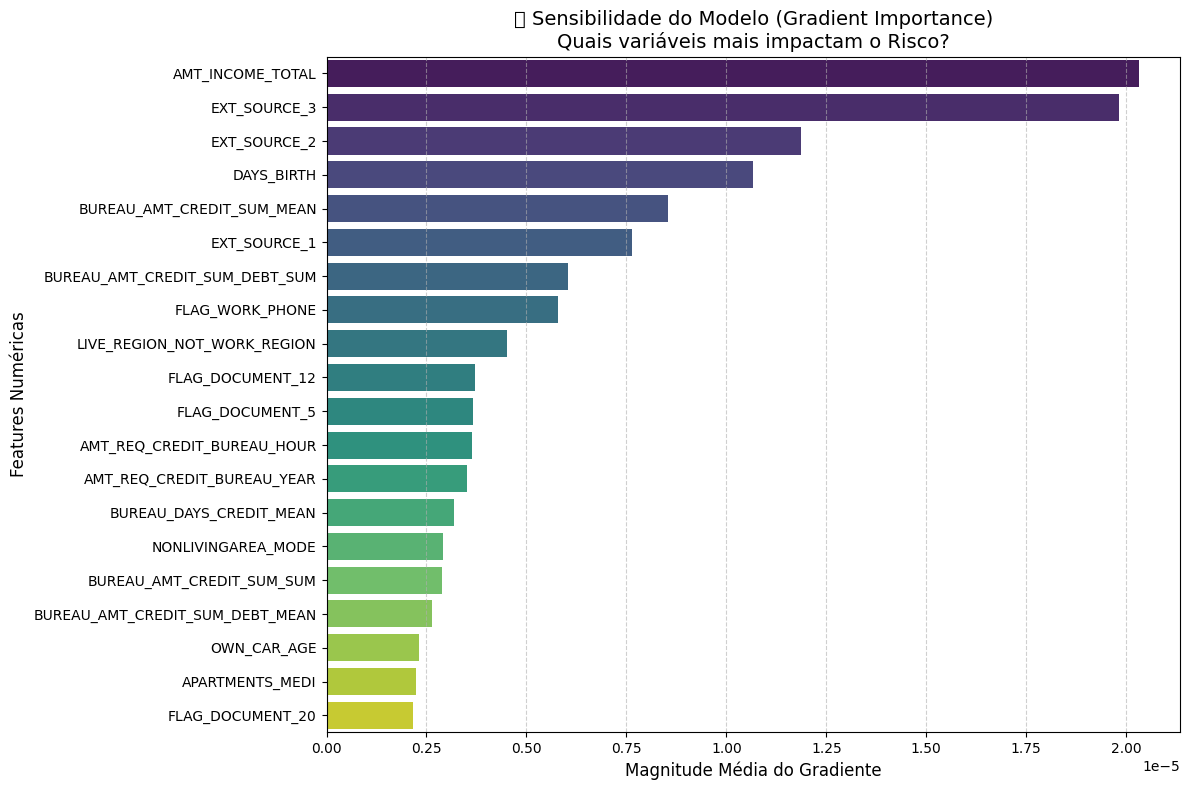


🏆 DOMINÂNCIA DO BUREAU NO GRADIENTE:
                            Feature  Importance
105      BUREAU_AMT_CREDIT_SUM_MEAN    0.000009
107  BUREAU_AMT_CREDIT_SUM_DEBT_SUM    0.000006
95       AMT_REQ_CREDIT_BUREAU_HOUR    0.000004


In [41]:
# Célula 22: Importância de Atributos via Sensibilidade (Gradientes)
# Esta célula calcula quais variáveis têm maior impacto na predição de Risco, usando a derivada da saída em relação à entrada.
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Preparar um batch de dados e habilitar o cálculo de gradientes na entrada
model.eval()
batch = next(iter(val_loader))
xn, xc = batch['xn'].to(device), batch['xc'].to(device)

# Habilitamos o rastreio de gradiente especificamente para as colunas numéricas
xn.requires_grad = True

# 2. Forward Pass
preds = model(xn, xc)
risk_output = torch.sigmoid(preds['risk'])

# 3. Backward Pass para calcular o gradiente da saída em relação à entrada
# Queremos ver como o risco médio do batch reage a cada feature
risk_output.mean().backward()

# 4. Extrair a magnitude dos gradientes (Importância)
# O gradiente indica a sensibilidade do modelo a cada coluna
importances = xn.grad.abs().mean(dim=0).cpu().numpy()

# 5. Mapear para os nomes das colunas numéricas
df_importance = pd.DataFrame({
    'Feature': num_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 6. Visualização das Top 20
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')
plt.title('📊 Sensibilidade do Modelo (Gradient Importance)\nQuais variáveis mais impactam o Risco?', fontsize=14)
plt.xlabel('Magnitude Média do Gradiente', fontsize=12)
plt.ylabel('Features Numéricas', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Destaque estatístico para a Tese
top_bureau = df_importance[df_importance['Feature'].str.contains('BUREAU')].head(3)
print("\n🏆 DOMINÂNCIA DO BUREAU NO GRADIENTE:")
print(top_bureau)

In [42]:
# Célula 23: Salvamento do Modelo e Metadados (Fase 2)
# É fundamental salvar não apenas os pesos do modelo, mas também os escalonadores e a lista de colunas para que o trabalho possa ser retomado sem perda de contexto.
import joblib

# 1. Definir o caminho e o dicionário de salvamento
model_path = 'ft_transformer_prescritivo_fase2.pt'
metadata_path = 'metadata_fase2.joblib'

print(f"💾 Salvando modelo e metadados em {model_path}...")

# 2. Salvar Pesos do Modelo (PyTorch)
torch.save({
    'epoch': 10,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'auc_score': 0.7235,
    'mae_prescritivo': 284635.78
}, model_path)

# 3. Salvar Scalers e Listas de Colunas (Joblib)
# Isso é essencial para garantir que a Fase 3 use a mesma normalização
metadata = {
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'cat_cardinalities': cat_cardinalities,
    'scaler_credit': scaler_credit_p,
    'scaler_annuity': scaler_annuity_p
}
joblib.dump(metadata, metadata_path)

print("✅ Tudo salvo com sucesso! O modelo está pronto para ser apresentado.")

💾 Salvando modelo e metadados em ft_transformer_prescritivo_fase2.pt...
✅ Tudo salvo com sucesso! O modelo está pronto para ser apresentado.
